In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully!\n")
print(df.head())


Dataset Loaded Successfully!

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [4]:
# Display the size of the dataset
print("Shape of the dataset:", df.shape)

# Display the column names
print("\nColumns in the dataset:")
print(df.columns)

# Display information about the dataset
print("\nDataset Information:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (398, 9)

Columns in the dataset:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_y

In [5]:
# Handle missing values

# Fill missing values in horsepower with the mean
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

# Select feature (X) and target (y)
X = df[['displacement']].values
y = df['mpg'].values

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Missing values after preprocessing:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Feature Shape: (398, 1)
Target Shape: (398,)


In [6]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [7]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Degree 2 Polynomial Regression
poly2 = PolynomialFeatures(degree=2)

# Convert X into polynomial features
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

# Train the model
poly_model2 = LinearRegression()
poly_model2.fit(X_train_poly2, y_train)

print("Polynomial Regression (Degree 2) trained successfully!")

Polynomial Regression (Degree 2) trained successfully!


In [9]:
# Degree 3 Polynomial Regression
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly_model3 = LinearRegression()
poly_model3.fit(X_train_poly3, y_train)

# Degree 4 Polynomial Regression
poly4 = PolynomialFeatures(degree=4)

X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

poly_model4 = LinearRegression()
poly_model4.fit(X_train_poly4, y_train)

print("Degree 3 and Degree 4 models trained successfully!")

Degree 3 and Degree 4 models trained successfully!


In [10]:
# Linear Regression Predictions
y_pred_linear = linear_model.predict(X_test)

# Polynomial Degree 2 Predictions
y_pred_poly2 = poly_model2.predict(X_test_poly2)

# Polynomial Degree 3 Predictions
y_pred_poly3 = poly_model3.predict(X_test_poly3)

# Polynomial Degree 4 Predictions
y_pred_poly4 = poly_model4.predict(X_test_poly4)

print("Predictions completed successfully!")

Predictions completed successfully!


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("------ MODEL COMPARISON ------\n")

# Linear Regression
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print(f"MSE : {mse_linear:.4f}")
print(f"R²  : {r2_linear:.4f}\n")

# Polynomial Degree 2
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Polynomial Regression (Degree 2)")
print(f"MSE : {mse_poly2:.4f}")
print(f"R²  : {r2_poly2:.4f}\n")

# Polynomial Degree 3
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print("Polynomial Regression (Degree 3)")
print(f"MSE : {mse_poly3:.4f}")
print(f"R²  : {r2_poly3:.4f}\n")

# Polynomial Degree 4
mse_poly4 = mean_squared_error(y_test, y_pred_poly4)
r2_poly4 = r2_score(y_test, y_pred_poly4)

print("Polynomial Regression (Degree 4)")
print(f"MSE : {mse_poly4:.4f}")
print(f"R²  : {r2_poly4:.4f}")

------ MODEL COMPARISON ------

Linear Regression
MSE : 18.1025
R²  : 0.6633

Polynomial Regression (Degree 2)
MSE : 15.1074
R²  : 0.7190

Polynomial Regression (Degree 3)
MSE : 14.9436
R²  : 0.7221

Polynomial Regression (Degree 4)
MSE : 14.9615
R²  : 0.7217


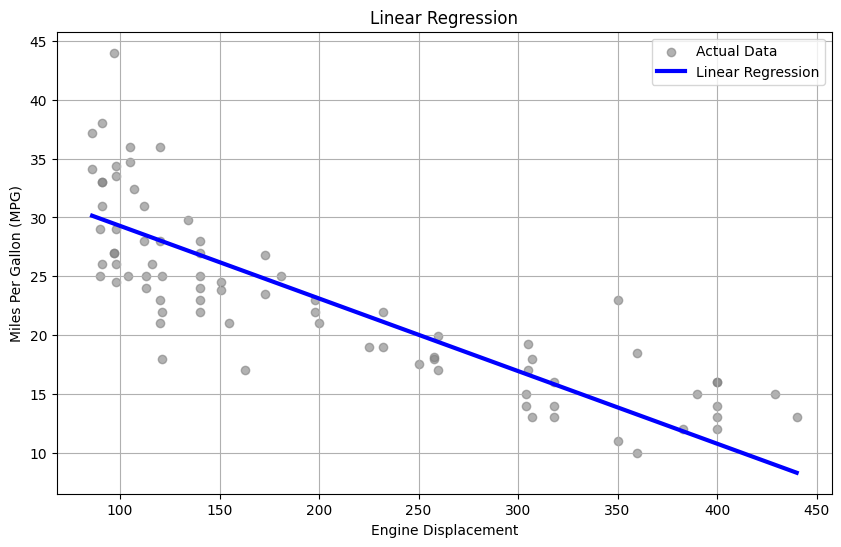

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Sort values for a smooth line
sort_index = np.argsort(X_test.flatten())

X_sorted = X_test.flatten()[sort_index]
y_sorted = y_test[sort_index]
y_pred_linear_sorted = y_pred_linear[sort_index]

plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    y_test,
    color='gray',
    alpha=0.6,
    label='Actual Data'
)

plt.plot(
    X_sorted,
    y_pred_linear_sorted,
    color='blue',
    linewidth=3,
    label='Linear Regression'
)

plt.title("Linear Regression")
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.legend()
plt.grid(True)

plt.show()

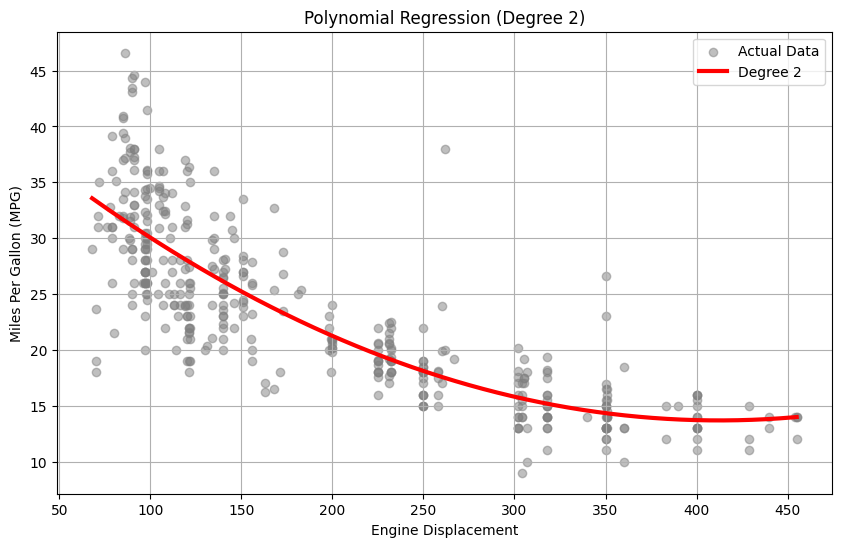

In [13]:
x_range = np.linspace(
    X.min(),
    X.max(),
    300
).reshape(-1,1)

x_poly2 = poly2.transform(x_range)
y_poly2 = poly_model2.predict(x_poly2)

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color='gray',
    alpha=0.5,
    label='Actual Data'
)

plt.plot(
    x_range,
    y_poly2,
    color='red',
    linewidth=3,
    label='Degree 2'
)

plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.legend()
plt.grid(True)

plt.show()

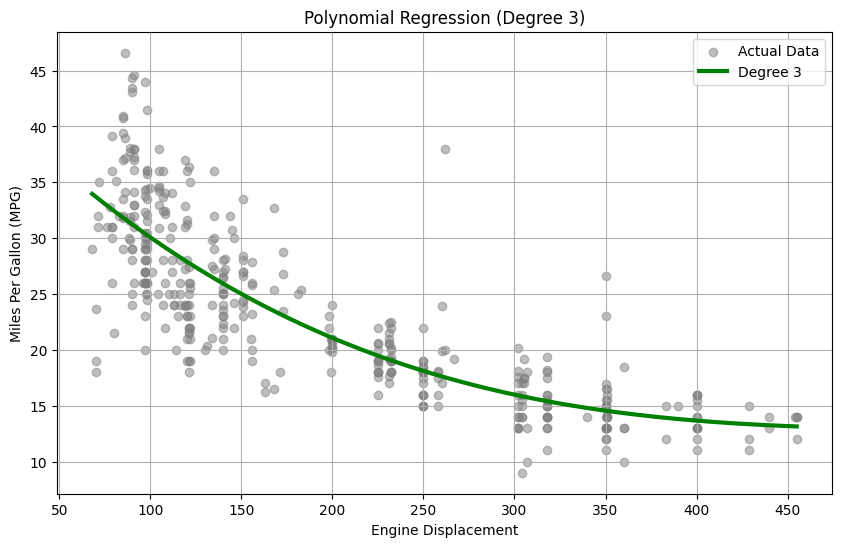

In [14]:
x_poly3 = poly3.transform(x_range)
y_poly3 = poly_model3.predict(x_poly3)

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color='gray',
    alpha=0.5,
    label='Actual Data'
)

plt.plot(
    x_range,
    y_poly3,
    color='green',
    linewidth=3,
    label='Degree 3'
)

plt.title("Polynomial Regression (Degree 3)")
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.legend()
plt.grid(True)

plt.show()

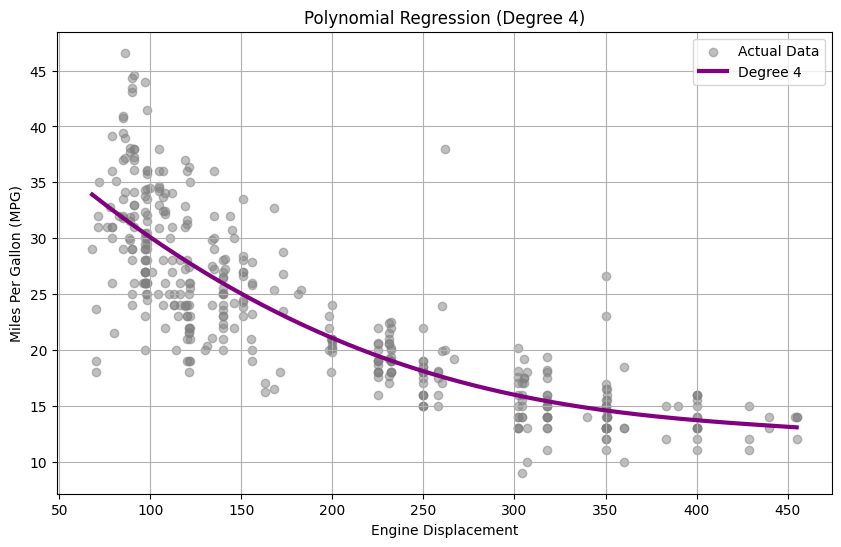

In [15]:
x_poly4 = poly4.transform(x_range)
y_poly4 = poly_model4.predict(x_poly4)

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color='gray',
    alpha=0.5,
    label='Actual Data'
)

plt.plot(
    x_range,
    y_poly4,
    color='purple',
    linewidth=3,
    label='Degree 4'
)

plt.title("Polynomial Regression (Degree 4)")
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.legend()
plt.grid(True)

plt.show()